# Fly Heaven: two MaleCNS connectome experiments

This notebook reruns two independent experiments on the same reconstructed wiring diagram — the **MaleCNS v1.0** connectome (Janelia / Google, CC BY 4.0) — on this machine, and checks the results against what each project published.

| | Fruitless | Fly / Wirehead |
|---|---|---|
| Question | Does blocking mAL output let candidate male sensory input excite P1-related courtship neurons? | What does the connectome do while it "watches" insect Shorts, with an artificial drive on its PAM11 dopamine neurons? |
| Source | `experiments/fruitless` ([nicodunks/fruitless](https://github.com/nicodunks/fruitless)) | `experiments/fly-wirehead` ([mattyhempstead/fly-wirehead](https://github.com/mattyhempstead/fly-wirehead)) |
| Graph | 166,606 classified neurons (excludes `tbc` superclasses), 25.57 M connections | 166,700 neurons (keeps `tbc`, drops glia), 25.58 M connections |
| Model | Numba leaky integrate-and-fire, bounded inhibitory conductance | C++ leaky integrate-and-fire with candidate KC→MBON07/11 plasticity |
| Run here | the 36 paired 300 ms trials behind its headline result | its full-network assay, then 15 s of its video feed |

Both projects download the same three source files (identical SHA-256 hashes, different file names), so the notebook downloads them once into `data/malecns-v1.0/` and links them into each project's expected layout. The projects' own simulation code runs unmodified — the notebook imports their functions rather than reimplementing them. Outputs go to `data/` and `runs/`, both git-ignored. Inside `experiments/`, the only files created are git-ignored caches. The one exception is fly-wirehead's video download script, which runs only if the MP4s are missing: it saves the videos (git-ignored) and rewrites the tracked `dist/media/playlist.json` with local file hashes.

**Costs:** ~1.1 GB download and ~2 GB of disk. Building the two graphs takes about a minute and several GB of RAM the first time; later runs skip it.

**Scope:** both are simplified models on real anatomy. Neither shows behaviour, mate preference, pleasure, or learning in a real fly — each section spells out what its result does and does not support.

In [1]:
import hashlib
import json
import os
import subprocess
import sys
import time
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.sparse import load_npz

ROOT = Path.cwd()
EXPERIMENTS = ROOT / "experiments"
FRUITLESS = EXPERIMENTS / "fruitless"
WIREHEAD = EXPERIMENTS / "fly-wirehead"
assert FRUITLESS.is_dir() and WIREHEAD.is_dir(), "Start Jupyter from the fly-heaven repository root"

DATA = ROOT / "data"
RAW = DATA / "malecns-v1.0"
FRUITLESS_DATA = DATA / "fruitless"
WIREHEAD_DATA = DATA / "fly-wirehead"
RUNS = ROOT / "runs"


def sha256(path):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        while block := handle.read(8 * 1024 * 1024):
            digest.update(block)
    return digest.hexdigest()


def sh(*args, cwd=ROOT):
    # Stream a subprocess into the notebook (plain subprocess.run output would bypass the cell).
    args = [str(a) for a in args]
    print("$", " ".join(args), flush=True)
    with subprocess.Popen(args, cwd=cwd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True) as process:
        for line in process.stdout:
            print(line, end="", flush=True)
    if process.returncode:
        raise subprocess.CalledProcessError(process.returncode, args)


# Chart styling: recessive chrome, fixed series order (validated categorical slots 1-3).
INK, INK_2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.size": 10, "text.color": INK, "axes.labelcolor": INK_2, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.edgecolor": AXIS,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "axes.grid.axis": "y",
    "grid.color": GRID, "grid.linewidth": 0.8, "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2, "legend.frameon": False,
    "lines.linewidth": 2, "figure.dpi": 110,
})
print(sys.version.split()[0], "| numpy", np.__version__, "| pandas", pd.__version__)

3.12.14 | numpy 2.5.3 | pandas 3.0.5


## 0 · Shared data: MaleCNS v1.0

The checksum lock comes from fly-wirehead; the cell first asserts that fruitless pins the same three hashes. Files are downloaded only if absent and are re-verified on every run.

In [2]:
lock = json.loads((WIREHEAD / "flywirehead/neural/sources.lock.json").read_text())
fruitless_pins = json.loads((FRUITLESS / "assets/circuit.json").read_text())["provenance"]["sha256"]
# Same files, different names in each project.
FRUITLESS_NAMES = {"annotations.feather": "annotations.feather",
                   "neurotransmitters.feather": "nt.feather",
                   "edges.feather": "graph.feather"}
for name, alias in FRUITLESS_NAMES.items():
    assert lock[name]["sha256"] == fruitless_pins[alias], f"Projects pin different {name}"

RAW.mkdir(parents=True, exist_ok=True)
for name, info in lock.items():
    path = RAW / name
    if not path.exists():
        print(f"Downloading {name} ({info['bytes'] / 1e6:,.0f} MB)…", flush=True)
        partial = path.with_suffix(".partial")
        urllib.request.urlretrieve(info["url"], partial)
        partial.replace(path)
    assert sha256(path) == info["sha256"], f"Checksum mismatch: {name}"
    print(f"verified  {name:27s} {path.stat().st_size / 1e6:>8,.1f} MB")


def link(directory, names):
    directory.mkdir(parents=True, exist_ok=True)
    for source, alias in names.items():
        target = directory / alias
        if not target.is_symlink() and not target.exists():
            target.symlink_to(os.path.relpath(RAW / source, directory))


link(FRUITLESS_DATA, FRUITLESS_NAMES)
link(WIREHEAD_DATA, {name: name for name in lock})

verified  annotations.feather             14.5 MB
verified  neurotransmitters.feather       43.3 MB


verified  edges.feather                1,051.2 MB


## 1 · Fruitless: does removing the mAL brake unmask a response to male cues?

**Background.** In flies, the GABAergic mAL neurons act as a brake on P1 courtship neurons; silencing mAL makes males court other males ([Kallman, Kim & Scott 2015](https://elifesciences.org/articles/11188)).

**Design** (frozen in [`BOUNDED_ROUTE_PROTOCOL.md`](experiments/fruitless/experiment/followup/BOUNDED_ROUTE_PROTOCOL.md)). The full graph receives 200 ms of Poisson input on one of three populations: 37 candidate *male-cue* foreleg neurons (LgLG6/7), 27 candidate *female-cue* neurons (LgLG5/8), or the 4 vAB3 relay neurons directly. Each trial is paired: the same network and the identical input event schedule, run once **intact** and once with **all outgoing transmission from 75 GABAergic mAL neurons blocked**. The readout is the spike total of eight literature-mapped P1 cells (pC1_4a/b) over the 250 ms response window, with no current injected into them. That's 2 inhibitory-reversal assumptions × 3 inputs × 3 seeds × 2 conditions = **36 runs**.

**History.** The project's first pilot (current-based inhibition, a broader 49-cell readout, conservative transmitter signs) found *zero* P1-related spikes in every trial ([`RESULTS.md`](experiments/fruitless/experiment/RESULTS.md)). This follow-up corrects the readout mapping, treats vAB3 output as excitatory, and bounds inhibition with a finite reversal potential ([`followup/RESULTS.md`](experiments/fruitless/experiment/followup/RESULTS.md)).

### 1.1 Build the graph

In [3]:
if not (FRUITLESS_DATA / "full-meta.json").exists():
    sh(sys.executable, FRUITLESS / "experiment/prepare.py", FRUITLESS_DATA)

meta = json.loads((FRUITLESS_DATA / "full-meta.json").read_text())
assert (meta["neurons"], meta["edges"]) == (166_606, 25_574_615), "Graph differs from the published pilot"
print(f"{meta['neurons']:,} neurons · {meta['edges']:,} connections · {meta['synapses']:,} synapses")
print("groups:", {name: len(cells) for name, cells in meta["groups"].items()})

166,606 neurons · 25,574,615 connections · 124,144,950 synapses
groups: {'candidate_male': 37, 'candidate_female': 27, 'mAL': 75, 'P1_related': 49, 'PPN1': 2}


### 1.2 Sanity checks on tiny networks

The project's own `verify.py`: excitation transmits, inhibition doesn't, blocked output is silent, and a network at rest stays silent.

In [4]:
sh(sys.executable, "verify.py", cwd=FRUITLESS / "experiment")

$ /home/anon/Downloads/fly-heaven/.venv/bin/python verify.py


PASS: excitatory transmission, inhibitory sign, blocked output, paired input, quiet baseline, silent recurrence


### 1.3 Run the 36 paired trials

This loop is the one in `followup/bounded_routes.py`, calling that file's Numba `run` kernel directly. The script's `main()` is not called because it would overwrite the published results inside `experiments/`. The first call includes JIT compilation.

In [5]:
# A regular import (not importlib-from-path) so Numba's on-disk cache can reload the kernel on later runs.
sys.path.insert(0, str(FRUITLESS / "experiment/followup"))
import bounded_routes as bounded

nodes = np.load(FRUITLESS_DATA / "full-nodes.npz")
ids = nodes["ids"]
W = load_npz(FRUITLESS_DATA / "full-graph.npz")
groups = {name: np.array(cells, np.int32) for name, cells in meta["groups"].items()}
# Body IDs fixed in bounded_routes.py (provenance in followup/MAPPING.md).
VAB3_IDS = [11998, 13341, 13693, 512498]
P1_IDS = [12442, 16719, 17867, 20117, 20803, 23968, 519518, 522419]
groups["vAB3"] = np.searchsorted(ids, VAB3_IDS)
p1 = np.searchsorted(ids, P1_IDS)
assert np.array_equal(ids[groups["vAB3"]], VAB3_IDS) and np.array_equal(ids[p1], P1_IDS)
mal = groups["mAL"]

# Sign assumptions shared by every input condition: vAB3 and female-cue outputs excitatory.
signs = nodes["signs"].copy()
signs[groups["vAB3"]] = 1
signs[groups["candidate_female"]] = 1

rows, p1_bins = [], {}
started = time.perf_counter()
for reversal in [-70.0, -80.0]:
    for population in ["candidate_male", "candidate_female", "vAB3"]:
        inputs = groups[population]
        rate = 150.0 if population == "vAB3" else 5550 / len(inputs)
        for seed in [11, 12, 13]:
            # One external schedule per pair, so intact and blocked receive identical input.
            events = np.zeros((3000, len(inputs)), np.bool_)
            events[500:2500] = np.random.RandomState(seed).random_sample((2000, len(inputs))) < rate * 0.1 / 1000
            for condition, name in [(1, "intact"), (2, "mAL_blocked")]:
                begin = time.perf_counter()
                counts, vmin, vmax = bounded.run(W.indptr, W.indices, W.data, signs, p1, mal, inputs, events, condition, reversal)
                assert vmin >= reversal - 1e-8, "Voltage fell below the inhibitory reversal"
                rows.append({
                    "reversal_mV": reversal, "input": population, "seed": seed, "condition": name,
                    "events": int(events.sum()), "event_sha256": hashlib.sha256(events.tobytes()).hexdigest(),
                    "P1_spikes": int(counts[5:, p1].sum()),
                    "broad_P1_spikes": int(counts[5:, groups["P1_related"]].sum()),
                    "mAL_spikes": int(counts[5:, mal].sum()),
                    "network_spikes": int(counts.sum()), "voltage_min_mV": vmin,
                })
                p1_bins[reversal, population, seed, name] = counts[:, p1].copy()
                r = rows[-1]
                print(f"{int(reversal)} mV  {population:16s} seed {seed}  {name:11s}  P1 {r['P1_spikes']:>3}  "
                      f"mAL {r['mAL_spikes']:>4}  network {r['network_spikes']:>7,}  ({time.perf_counter() - begin:.1f} s)", flush=True)

fruitless_runs = pd.DataFrame(rows)
(RUNS / "fruitless").mkdir(parents=True, exist_ok=True)
fruitless_runs.to_csv(RUNS / "fruitless/bounded-routes.csv", index=False)
print(f"\n{len(rows)} runs in {time.perf_counter() - started:.0f} s")

-70 mV  candidate_male   seed 11  intact       P1   0  mAL   77  network   6,844  (5.5 s)


-70 mV  candidate_male   seed 11  mAL_blocked  P1   4  mAL  115  network   6,108  (5.4 s)


-70 mV  candidate_male   seed 12  intact       P1   0  mAL   79  network  14,817  (5.5 s)


-70 mV  candidate_male   seed 12  mAL_blocked  P1   5  mAL  107  network   5,330  (5.4 s)


-70 mV  candidate_male   seed 13  intact       P1   0  mAL   80  network   7,040  (5.4 s)


...

-80 mV  vAB3             seed 12  intact       P1   0  mAL  313  network   3,699  (5.3 s)


-80 mV  vAB3             seed 12  mAL_blocked  P1  15  mAL  400  network   7,422  (5.3 s)


-80 mV  vAB3             seed 13  intact       P1   0  mAL  332  network   6,514  (5.4 s)


-80 mV  vAB3             seed 13  mAL_blocked  P1  12  mAL  432  network  28,029  (5.4 s)



36 runs in 194 s


### 1.4 Does it reproduce the published run?

Compare every run field by field with the project's committed `bounded-route-results.json`.

In [6]:
published = pd.DataFrame(json.loads((FRUITLESS / "experiment/followup/bounded-route-results.json").read_text())["results"])
key = ["reversal_mV", "input", "seed", "condition"]
merged = fruitless_runs.merge(published, on=key, suffixes=("", "_published"), validate="one_to_one")
assert len(merged) == len(published) == 36
fields = ["events", "event_sha256", "P1_spikes", "broad_P1_spikes", "mAL_spikes", "network_spikes"]
reproduced = {field: bool((merged[field] == merged[f"{field}_published"]).all()) for field in fields}
reproduced["voltage_min_mV (±1e-6)"] = bool(np.allclose(merged["voltage_min_mV"], merged["voltage_min_mV_published"], atol=1e-6))
pd.Series(reproduced, name="identical in all 36 runs").to_frame()

,identical in all 36 runs
events,True
event_sha256,True
P1_spikes,True
broad_P1_spikes,True
mAL_spikes,True
network_spikes,True
voltage_min_mV (±1e-6),True


In [7]:
paired = (fruitless_runs.pivot_table(index=["reversal_mV", "input", "seed"], columns="condition", values="P1_spikes")
          [["intact", "mAL_blocked"]].astype(int))
paired["change"] = paired["mAL_blocked"] - paired["intact"]
paired

condition                          intact  mAL_blocked  change
reversal_mV input            seed                             
-80.0       candidate_female 11        10           21      11
                             12        10           23      13
                             13         9           22      13
            candidate_male   11         0            4       4
                             12         0            7       7
                             13         0            1       1
            vAB3             11         0           10      10
                             12         0           15      15
                             13         0           12      12
-70.0       candidate_female 11        11           18       7
                             12         8           18      10
                             13         8           20      12
            candidate_male   11         0            4       4
                             12         0            5       5
                             13         0            1       1
            vAB3             11         0           13      13
                             12         0            9       9
                             13         0           12      12

### 1.5 The result

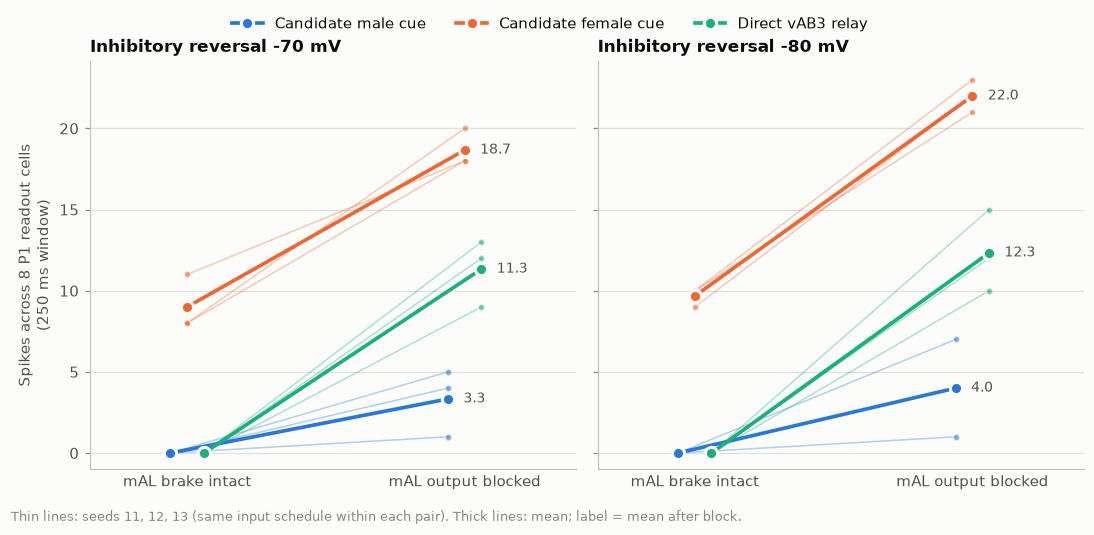

In [8]:
INPUTS = [("candidate_male", "Candidate male cue", BLUE),
          ("candidate_female", "Candidate female cue", ORANGE),
          ("vAB3", "Direct vAB3 relay", AQUA)]
fig, axes = plt.subplots(1, 2, figsize=(10, 4.4), sharey=True)
for ax, reversal in zip(axes, [-70.0, -80.0]):
    for k, (population, label, color) in enumerate(INPUTS):
        pairs = paired.loc[(reversal, population)]
        x = np.array([0, 1]) + (k - 1) * 0.06
        for _, pair in pairs.iterrows():
            ax.plot(x, [pair["intact"], pair["mAL_blocked"]], color=color, lw=1, alpha=0.35)
            ax.scatter(x, [pair["intact"], pair["mAL_blocked"]], s=18, color=color, alpha=0.6, edgecolors=SURFACE, linewidths=1, zorder=3)
        mean = pairs[["intact", "mAL_blocked"]].mean()
        ax.plot(x, mean, color=color, lw=2.4, marker="o", markersize=8, markeredgecolor=SURFACE, markeredgewidth=2, label=label, zorder=4)
        ax.annotate(f"{mean['mAL_blocked']:.1f}", (x[1], mean["mAL_blocked"]), xytext=(10, 0), textcoords="offset points",
                    va="center", color=INK_2, fontsize=9)
    ax.set_xticks([0, 1], ["mAL brake intact", "mAL output blocked"])
    ax.set_xlim(-0.35, 1.4)
    ax.tick_params(axis="x", length=0)
    ax.set_title(f"Inhibitory reversal {int(reversal)} mV")
axes[0].set_ylabel("Spikes across 8 P1 readout cells\n(250 ms window)")
axes[0].set_ylim(bottom=-1)
fig.legend(*axes[0].get_legend_handles_labels(), loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.04))
fig.text(0.01, -0.03, "Thin lines: seeds 11, 12, 13 (same input schedule within each pair). Thick lines: mean; label = mean after block.",
         color=MUTED, fontsize=8.5)
fig.tight_layout()
plt.show()

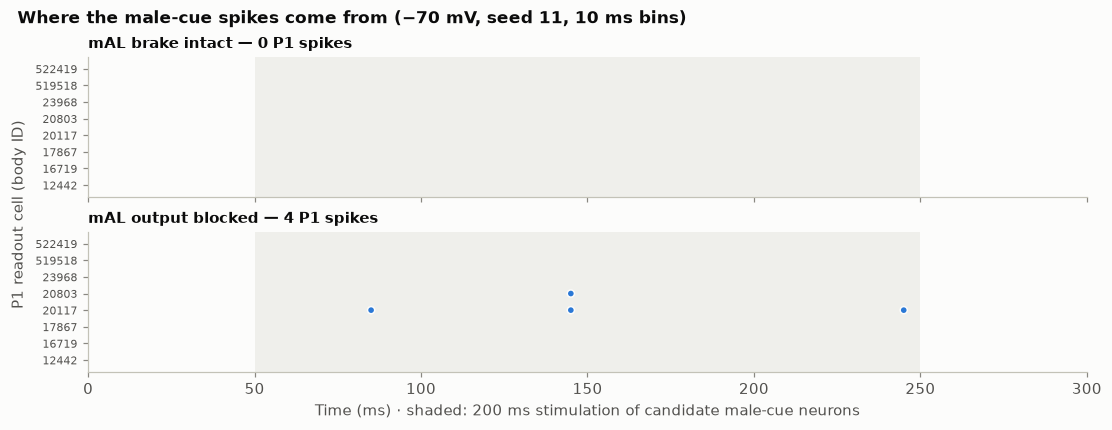

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(10, 3.8), sharex=True, layout="constrained")
for ax, condition, title in zip(axes, ["intact", "mAL_blocked"], ["mAL brake intact", "mAL output blocked"]):
    bins = p1_bins[-70.0, "candidate_male", 11, condition]
    b, cell = np.nonzero(bins)
    ax.axvspan(50, 250, color=GRID, alpha=0.45, lw=0)
    ax.scatter(b * 10 + 5, cell, s=12 + 10 * bins[b, cell], color=BLUE, edgecolors=SURFACE, linewidths=1, zorder=3)
    ax.set_yticks(range(8), [f"{i}" for i in P1_IDS], fontsize=7.5)
    ax.set_ylim(-0.7, 7.7)
    ax.grid(False)
    ax.set_title(f"{title} — {int(bins[5:].sum())} P1 spikes", fontsize=10)
axes[1].set_xlabel("Time (ms) · shaded: 200 ms stimulation of candidate male-cue neurons")
axes[1].set_xlim(0, 300)
fig.supylabel("P1 readout cell (body ID)", color=INK_2, fontsize=10)
fig.suptitle("Where the male-cue spikes come from (−70 mV, seed 11, 10 ms bins)", x=0.01, ha="left", fontweight="bold", fontsize=11)
plt.show()

**What this shows.** With the brake intact, candidate male-cue input produces no P1 readout spikes. With mAL output blocked, the same input produces a small response in every seed under both inhibition assumptions. Female-cue input gives a larger response than male-cue input in both conditions, so this is **disinhibition, not a switch in preference**. Stimulating vAB3 directly (the relay that the courtship literature places upstream of P1) shows the same unmasking.

**What it does not show.** Transmitter signs, the vAB3 and female-input overrides, the readout identity (only 8 direct vAB3→pC1_4a/b synapses — see [`MAPPING.md`](experiments/fruitless/experiment/followup/MAPPING.md)), and the uniform Poisson input encoding are all model assumptions. The three seeds are technical replicates. Nothing here models movement or mate choice.

Free the graph before loading the second one:

In [10]:
del W, nodes, bounded

## 2 · Fly / Wirehead: a connectome that watches Shorts

**Setup** ([`docs/model.md`](experiments/fly-wirehead/docs/model.md)). In the live app, the browser renders a phone playing insect Shorts, captures its screen at **90×160 px**, and sends each frame to the brain. Pixel luminance drives **3,335 R1–R6 photoreceptor inputs**, and pixel colour drives **811 R8 inputs**. Each frame advances **50 ms of neural time** in a compiled C++ kernel at 0.1 ms steps. While video is playing, a fixed **20 mV-equivalent current** is applied to the **15 PAM11 dopamine neurons** (the "reward"). A candidate plasticity rule can modify the 7,835 existing KC→MBON07/11 synapses.

Here the app's browser and 3D scene are replaced with direct calls to its `FlyEngine`, the same object its server uses.

### 2.1 Build the graph and compile the kernel

`FLYWIREHEAD_DATA` must be set before `flywirehead` is imported, because the package reads it at import time.

**A build detail that changes the results.** The kernel integrates the network in float32, and the dynamics are chaotic enough that rounding differences grow into a different trajectory within the 1.5 s conditioning period below. The project's published numbers come from Apple silicon, where clang fuses multiply-adds (FMA) by default; on x86-64, the project's own compiler flags don't fuse them. With those flags, the machine that generated this notebook got 80,958 white-screen spikes instead of 127,378, and only 5 plastic synapses changed instead of 3,087. The project's own full-network test (`tests/test_full_connectome.py:42`) also fails with that build. Compiling the same source with `-mfma -ffp-contract=fast` reproduced every published value exactly. So on x86-64 this cell builds a separate FMA copy of the kernel and points the engine at it. Set `MATCH_PUBLISHED_BUILD = False` to use the project's own flags instead.

In [11]:
import platform

os.environ["FLYWIREHEAD_DATA"] = str(WIREHEAD_DATA)
sys.path.insert(0, str(WIREHEAD))
import flywirehead.neural.brain as wirehead_brain
from flywirehead.data import prepare as prepare_wirehead
from flywirehead.engine import FlyEngine

prepare_wirehead()  # builds normalized tables + graph.npz once; afterwards only verifies them against the locks

MATCH_PUBLISHED_BUILD = True


def cpu_has_fma():
    info = Path("/proc/cpuinfo")
    return info.exists() and any("fma" in line.split() for line in info.read_text().splitlines() if line.startswith("flags"))


if MATCH_PUBLISHED_BUILD and platform.machine() == "x86_64" and cpu_has_fma():
    flags = ["-O3", "-mfma", "-ffp-contract=fast", "-std=c++17", "-shared", "-fPIC"]
    library = WIREHEAD_DATA / "cache/physiology-v6-fma/libmemory.so"
    record_path = library.with_suffix(".so.json")
    source_sha = sha256(wirehead_brain.SOURCE)
    record = json.loads(record_path.read_text()) if record_path.exists() else {}
    if record.get("source_sha256") != source_sha or record.get("flags") != flags or not library.exists():
        library.parent.mkdir(parents=True, exist_ok=True)
        subprocess.run(["c++", *flags, str(wirehead_brain.SOURCE), "-o", str(library)], check=True)
        record = {"model": wirehead_brain.MODEL, "source_sha256": source_sha, "binary_sha256": sha256(library), "flags": flags}
        record_path.write_text(json.dumps(record, indent=2))
    wirehead_brain.LIBRARY = library  # the project's build() accepts this verified binary instead of compiling its default

started = time.perf_counter()
engine = FlyEngine()
brain = engine.brain
print(f"loaded in {time.perf_counter() - started:.0f} s: {brain.n:,} neurons · {len(brain.post):,} connections · "
      f"{len(brain.retina):,} R1–R6 · {len(brain.r8)} R8 · {len(brain.circuit['reward'])} PAM11 · "
      f"{len(brain.circuit['edges']):,} plastic KC→MBON synapses")
print("kernel flags:", " ".join(brain.build["flags"]))

{"release": "MaleCNS v1.0", "neurons": 166700, "directed_edges": 25582938, "arrays_verified": true}


loaded in 2 s: 166,700 neurons · 25,582,938 connections · 3,335 R1–R6 · 811 R8 · 15 PAM11 · 7,835 plastic KC→MBON synapses
kernel flags: -O3 -mfma -ffp-contract=fast -std=c++17 -shared -fPIC


### 2.2 The project's full-network assay

This repeats `tests/test_full_connectome.py`. The brain is conditioned with 1.5 s of white screen and checkpointed. Each probe below then starts from that checkpoint:

- black vs white screen (100 ms)
- control vs PAM11-stimulated observation (200 ms)
- exact replay after restoring the checkpoint
- frozen plasticity

The published values come from [`docs/validation.md`](experiments/fly-wirehead/docs/validation.md).

In [12]:
white = np.full((160, 90, 3), 255, np.uint8)
black = np.zeros_like(white)
edges = brain.circuit["edges"]

started = time.perf_counter()
for _ in range(3):
    engine.observe(white, 500)
checkpoint = RUNS / "fly-wirehead" / "conditioned.npz"
brain.checkpoint(checkpoint)
conditioned_weights = brain.weight[edges].copy()

dark = engine.observe(black, 100); brain.restore(checkpoint)
light = engine.observe(white, 100); brain.restore(checkpoint)
control = engine.observe(white, 200)
control_weights = brain.weight[edges].copy(); brain.restore(checkpoint)
engine.stimulate()
pulse = engine.observe(white, 200)
drive_changed_weights = not np.array_equal(brain.weight[edges], control_weights); brain.restore(checkpoint)
watching = engine.observe(white, 200, video_reward=True); brain.restore(checkpoint)
replay = engine.observe(white, 200); brain.restore(checkpoint)
brain.weights_frozen = True
frozen = engine.observe(white, 200, video_reward=True)
frozen_preserved = bool(np.array_equal(brain.weight[edges], conditioned_weights))
brain.restore(checkpoint)  # also restores weights_frozen=False
print(f"assay: {time.perf_counter() - started:.0f} s for {brain.sim_ms / 1000 + 1.1:.1f} s of neural time")

assay = pd.DataFrame([
    ("Network spikes, 100 ms white screen", 127_378, light["total_spikes"]),
    ("Network spikes, 100 ms black screen", 92_952, dark["total_spikes"]),
    ("PAM11 spikes, 200 ms control", 0, control["pam11_spikes"]),
    ("PAM11 spikes, 200 ms with 20 mV drive", 261, pulse["pam11_spikes"]),
    ("Plastic synapses changed after the drive", 3_087, pulse["memory"]["changed_edges"]),
    ("Drive changes plastic weights vs control (test line 42)", True, drive_changed_weights),
    ("Video drive = manual pulse (spike hash)", True, watching["spike_sha256"] == pulse["spike_sha256"]),
    ("Replay from checkpoint is exact (spike hash)", True, replay["spike_sha256"] == control["spike_sha256"]),
    ("Frozen plasticity keeps weights", True, frozen_preserved and frozen["pam11_spikes"] > 0),
], columns=["measure", "published", "this run"]).set_index("measure")
assay["match"] = assay["published"] == assay["this run"]
assay

assay: 21 s for 2.6 s of neural time


,published,this run,match
measure,,,
"Network spikes, 100 ms white screen",127378,127378,True
"Network spikes, 100 ms black screen",92952,92952,True
"PAM11 spikes, 200 ms control",0,0,True
"PAM11 spikes, 200 ms with 20 mV drive",261,261,True
Plastic synapses changed after the drive,3087,3087,True
Drive changes plastic weights vs control (test line 42),True,True,True
Video drive = manual pulse (spike hash),True,True,True
Replay from checkpoint is exact (spike hash),True,True,True
Frozen plasticity keeps weights,True,True,True


### 2.3 Watch the feed

The five Shorts from `video-sources.json` are decoded at 20 fps and scaled to 90×160, so each frame stands in for exactly 50 ms of neural time. The app swipes to the next Short after 3 s, so each clip contributes 60 frames, giving 15 s of neural time per condition.

The feed is shown twice from the same fresh brain: once **with** the automatic PAM11 drive (the app's default) and once **without** it (the app's `--no-video-reward` control). Two things differ from the live app. There, the frame sent is whatever is on screen when the worker is ready, so video and neural time only loosely track each other. The app also renders the phone through WebGL instead of using ffmpeg's downscale.

If the prepared MP4s are missing, the project's download script fetches them with `yt-dlp` and `ffmpeg`. It also rewrites the tracked `dist/media/playlist.json` with this machine's file hashes; `git -C experiments/fly-wirehead checkout dist/media/playlist.json` restores the committed version, and nothing reads those hashes.

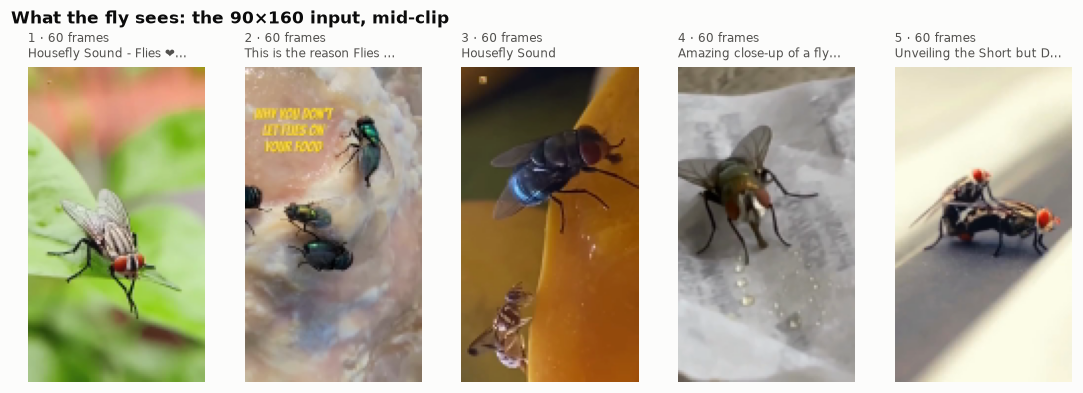

In [13]:
FPS = 20                 # one frame per 50 ms of neural time
SECONDS_PER_CLIP = 3.0   # the app's swipe interval
MEDIA = WIREHEAD / "dist/media"

playlist = json.loads((MEDIA / "playlist.json").read_text())["clips"]
if not all((MEDIA / clip["file"]).exists() for clip in playlist):
    sh(sys.executable, "scripts/download_videos.py", cwd=WIREHEAD)
    playlist = json.loads((MEDIA / "playlist.json").read_text())["clips"]


def decode(path):
    raw = subprocess.run(
        ["ffmpeg", "-v", "error", "-i", str(path), "-t", str(SECONDS_PER_CLIP),
         "-vf", f"fps={FPS},scale=90:160:flags=area", "-f", "rawvideo", "-pix_fmt", "rgb24", "-"],
        check=True, capture_output=True).stdout
    return np.frombuffer(raw, np.uint8).reshape(-1, 160, 90, 3)


feed = [(clip, decode(MEDIA / clip["file"])) for clip in playlist]

fig, axes = plt.subplots(1, len(feed), figsize=(10, 3.6))
for i, (ax, (clip, frames)) in enumerate(zip(axes, feed), start=1):
    ax.imshow(frames[len(frames) // 2])
    ax.set_axis_off()
    title = clip["title"] if len(clip["title"]) <= 26 else clip["title"][:25] + "…"
    ax.set_title(f"{i} · {len(frames)} frames\n{title}", fontsize=8, fontweight="normal", color=INK_2)
fig.suptitle("What the fly sees: the 90×160 input, mid-clip", x=0.01, ha="left", fontweight="bold", fontsize=11)
fig.tight_layout()
plt.show()

In [14]:
def watch(video_reward):
    brain.reset()                 # fresh neural state and baseline plastic weights
    engine.pending_pulse_ms = 0.0
    samples = []
    for index, (clip, frames) in enumerate(feed, start=1):
        begin = time.perf_counter()
        for frame in frames:
            t = engine.observe(frame, 50.0, video_reward=video_reward)
            samples.append({
                "video_drive": video_reward, "clip": index, "time_s": t["sim_ms"] / 1000,
                "pam11_hz": t["pam11_hz"], "network_spikes": t["total_spikes"], "kc_hz": t["kc_hz"],
                "motor_hz": t["motor_hz"], "turn_hz": t["turn_hz"],
                "changed_synapses": t["memory"]["changed_edges"], "mean_efficacy": t["memory"]["mean_efficacy"],
            })
        print(f"video drive {'on ' if video_reward else 'off'}  clip {index}: {len(frames)} frames in {time.perf_counter() - begin:.0f} s", flush=True)
    return pd.DataFrame(samples)


feed_runs = pd.concat([watch(True), watch(False)], ignore_index=True)
feed_runs.to_csv(RUNS / "fly-wirehead/feed.csv", index=False)

video drive on   clip 1: 60 frames in 16 s


video drive on   clip 2: 60 frames in 18 s


video drive on   clip 3: 60 frames in 18 s


video drive on   clip 4: 60 frames in 18 s


video drive on   clip 5: 60 frames in 18 s


video drive off  clip 1: 60 frames in 16 s


video drive off  clip 2: 60 frames in 18 s


video drive off  clip 3: 60 frames in 18 s


video drive off  clip 4: 60 frames in 18 s


video drive off  clip 5: 60 frames in 18 s


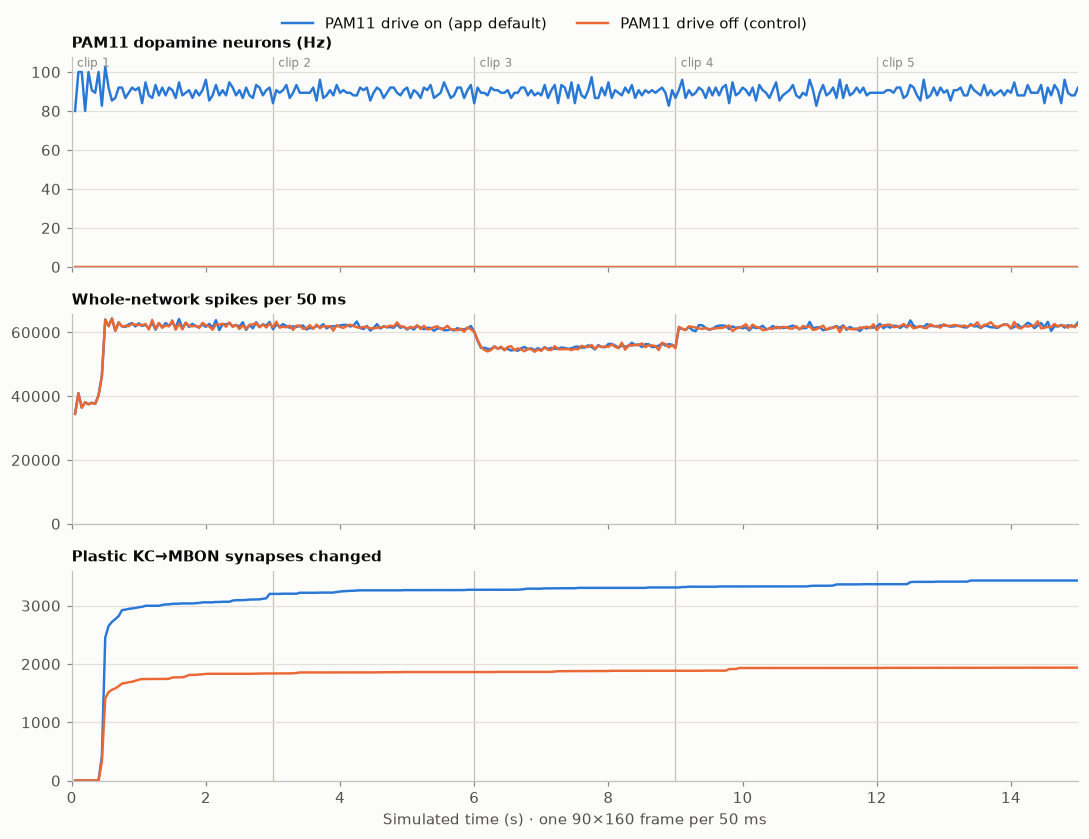

In [15]:
CONDITIONS = [(True, "PAM11 drive on (app default)", BLUE), (False, "PAM11 drive off (control)", ORANGE)]
PANELS = [("pam11_hz", "PAM11 dopamine neurons (Hz)"),
          ("network_spikes", "Whole-network spikes per 50 ms"),
          ("changed_synapses", "Plastic KC→MBON synapses changed")]
clip_starts = feed_runs[feed_runs.video_drive].groupby("clip").time_s.min() - 0.05

fig, axes = plt.subplots(len(PANELS), 1, figsize=(10, 7.5), sharex=True)
for ax, (column, title) in zip(axes, PANELS):
    for drive, label, color in CONDITIONS:
        series = feed_runs[feed_runs.video_drive == drive]
        ax.plot(series.time_s, series[column], color=color, lw=1.6, label=label)
    for start in clip_starts.iloc[1:]:
        ax.axvline(start, color=AXIS, lw=0.8, zorder=0)
    ax.set_title(title, fontsize=10)
    ax.set_ylim(bottom=0)
for clip, start in clip_starts.items():
    axes[0].annotate(f"clip {clip}", (start + 0.08, 1.0), xycoords=("data", "axes fraction"), va="top", color=MUTED, fontsize=8)
axes[-1].set_xlabel("Simulated time (s) · one 90×160 frame per 50 ms")
axes[-1].set_xlim(0, feed_runs.time_s.max())
fig.legend(*axes[0].get_legend_handles_labels(), loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02))
fig.tight_layout()
plt.show()

In [16]:
summary = feed_runs.groupby(["video_drive", "clip"]).agg(
    pam11_hz=("pam11_hz", "mean"), network_spikes=("network_spikes", "mean"),
    kc_hz=("kc_hz", "mean"), motor_hz=("motor_hz", "mean"),
    changed_synapses=("changed_synapses", "last"), mean_efficacy=("mean_efficacy", "last"))
summary.round(3)

pam11_hz  network_spikes  kc_hz  motor_hz  changed_synapses  \
video_drive clip                                                                
False       1        0.000       58663.033  1.999     6.750              1838   
            2        0.000       61573.417  2.190     6.583              1862   
            3        0.000       55249.950  2.191     7.833              1884   
            4        0.000       61385.733  2.253     8.667              1932   
            5        0.000       62033.583  2.195     8.833              1937   
True        1       90.244       58748.750  1.970     7.500              3202   
            2       89.822       61562.183  2.186     7.417              3272   
            3       89.733       55383.250  2.198     9.167              3312   
            4       89.911       61444.917  2.213     7.917              3368   
            5       89.867       61983.783  2.212     6.250              3431   

                  mean_efficacy  
video_drive clip                 
False       1             1.003  
            2             0.996  
            3             1.002  
            4             0.999  
            5             1.000  
True        1             1.021  
            2             1.023  
            3             1.021  
            4             1.019  
            5             1.019

**What this shows** (numbers from the run on the machine that generated this notebook; the table above has the exact values):

- **PAM11 firing is the injected current.** With the drive on, the 15 PAM11 cells fire at about 90 Hz in every clip. The project reported 84–97 Hz in its live app. With the drive off they don't fire at all, and in neither condition does their rate track which clip is playing.
- **The picture does reach the network.** Whole-network activity settles at roughly 55,000–63,000 spikes per 50 ms; the project's live audit reported a median of 61,731. Activity shifts with the clip: clip 3 runs about 10% lower in both conditions. The PAM11 drive barely changes whole-network activity.
- **Plasticity runs with or without the drive.** Once activity ramps up at about 0.5 s, the rule rewrites KC→MBON synapses in both conditions: about 1,900 synapses change without the drive and 3,400 with it. Without the drive, the changes roughly cancel and mean efficacy stays near 1.00× baseline. With it, mean efficacy rises to about 1.02×. These efficacy figures depend on the trajectory: with the project's non-FMA compiler flags (§2.1), the no-drive run drifted down to 0.94× instead.

**What it does not show.** The "dopamine" signal is a firing rate produced by an injected current, not a response to the content. A changed weight isn't evidence of learning, preference, pleasure, or addiction. The fly doesn't choose videos, and the photoreceptor model is a display proxy, not calibrated fly vision.

## Next

- Live 3D versions: `cd experiments/fly-wirehead && uv run flywirehead run` (a garden chamber with a phone, port 4173) and `cd experiments/fruitless && npm install && npm start` (replay of recorded spikes, port 8000).
- On x86-64 the live fly-wirehead app compiles its kernel with the project's own flags, so it follows the non-FMA trajectory described in §2.1, not the published one.
- Raw results from this notebook: `runs/fruitless/bounded-routes.csv` and `runs/fly-wirehead/feed.csv`.
- Fruitless also ships the mechanism-only brake assay (`followup/brake.py`, ~100 runs of 700 ms), which is not rerun here.